# Intro
This notebook will build a GCN  + GRU model to predict station demand at timestep T. This will be based off a flow based adjacency between stations to construct our adjacency matrix.

In [2]:
from google.colab import drive
drive.mount('/content/drive')
import os, shutil, subprocess

WORK_DIR = '/content/drive/MyDrive/DL_Project'
os.chdir(WORK_DIR)
print('cwd:', os.getcwd())

Mounted at /content/drive
cwd: /content/drive/.shortcut-targets-by-id/1cv6g42seKHWos13nKtt695z3yVVUNFOn/DL_Project


In [3]:
%pip install torch_geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 82.9 MB/s eta 0:00:00


In [4]:
import os
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"  # make cuda error synchonous

In [5]:
import polars as pl
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader


from torch_geometric.nn.conv import GCNConv
from torch_geometric.nn.conv.gcn_conv import gcn_norm


# Data readin

In [6]:
# read in cabi data
cabi = pl.read_parquet('data/cabi_combined_data.parquet').with_columns([
    pl.col("start_station_id").cast(pl.Int64),
    pl.col("end_station_id").cast(pl.Int64),
])

In [7]:
cabi.head(10)

ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual,_source_zip,_source_file
str,str,str,str,str,i64,str,i64,f64,f64,f64,f64,str,str,str
"""1B4445D591115BD9""","""classic_bike""","""2022-01-06 18:39:28""","""2022-01-06 18:43:03""","""Monroe Ave & Leslie Ave""",31087,"""Potomac Ave & Main Line Blvd""",31910,38.820932,-77.053096,38.822738,-77.049265,"""member""","""202201-capitalbikeshare-tripda…","""202201-capitalbikeshare-tripda…"
"""7F4A0E2F03EADEB7""","""classic_bike""","""2022-01-31 19:21:22""","""2022-01-31 19:27:33""","""14th & L St NW""",31283,"""10th & G St NW""",31274,38.903658,-77.031737,38.898243,-77.026235,"""member""","""202201-capitalbikeshare-tripda…","""202201-capitalbikeshare-tripda…"
"""30DD8A84164843AD""","""classic_bike""","""2022-01-07 15:28:39""","""2022-01-07 15:31:01""","""14th & L St NW""",31283,"""12th & L St NW""",31251,38.903658,-77.031737,38.903819,-77.0284,"""member""","""202201-capitalbikeshare-tripda…","""202201-capitalbikeshare-tripda…"
"""FC67665D7682D0A6""","""classic_bike""","""2022-01-27 20:09:25""","""2022-01-27 20:37:02""","""New York Ave & Hecht Ave NE""",31518,"""Nannie Helen Burroughs & Minne…",31704,38.915604,-76.983683,38.901385,-76.941877,"""casual""","""202201-capitalbikeshare-tripda…","""202201-capitalbikeshare-tripda…"
"""7854F7CC4F631A1E""","""classic_bike""","""2022-01-07 16:14:28""","""2022-01-07 16:16:13""","""Falls Church City Hall / Park …",32608,"""Pennsylvania Ave & Park Ave""",32603,38.885434,-77.173605,38.887403,-77.176992,"""member""","""202201-capitalbikeshare-tripda…","""202201-capitalbikeshare-tripda…"
"""FBDCB4296C2A0B2E""","""classic_bike""","""2022-01-24 19:50:35""","""2022-01-24 20:07:00""","""14th & L St NW""",31283,"""Park Rd & Holmead Pl NW""",31602,38.903658,-77.031737,38.9308,-77.0315,"""casual""","""202201-capitalbikeshare-tripda…","""202201-capitalbikeshare-tripda…"
"""6B14178CB767703A""","""classic_bike""","""2022-01-26 19:37:48""","""2022-01-26 19:48:50""","""Adams Mill & Columbia Rd NW""",31104,"""3rd & Elm St NW""",31118,38.922925,-77.042581,38.917622,-77.01597,"""casual""","""202201-capitalbikeshare-tripda…","""202201-capitalbikeshare-tripda…"
"""390C77E802B77D91""","""classic_bike""","""2022-01-15 10:12:52""","""2022-01-15 10:22:15""","""14th & Harvard St NW""",31105,"""11th & S St NW""",31280,38.9268,-77.0322,38.913761,-77.027025,"""member""","""202201-capitalbikeshare-tripda…","""202201-capitalbikeshare-tripda…"
"""131937550248E68C""","""electric_bike""","""2022-01-08 11:48:59""","""2022-01-08 11:56:21""","""14th & Harvard St NW""",31105,"""Calvert St & Woodley Pl NW""",31121,38.926775,-77.032137,38.923583,-77.050046,"""casual""","""202201-capitalbikeshare-tripda…","""202201-capitalbikeshare-tripda…"


# Construct Flow Adjacency

In [8]:
# convert these to int since the code below won't work otherwise
cabi = cabi.with_columns([
    pl.col("start_station_id").cast(pl.Int64),
    pl.col("end_station_id").cast(pl.Int64)
])

In [9]:
# compute bidirectional step counts between stations

flow_df = cabi.filter(pl.col("start_station_id").is_not_null() &
            pl.col("end_station_id").is_not_null() &
            pl.col("start_station_id") != pl.col("end_station_id")
            ).select(["start_station_id", "end_station_id"]
            ).with_columns([
                # compute as directed edge
               pl.min_horizontal("start_station_id", "end_station_id").alias("source"),
                pl.max_horizontal("start_station_id", "end_station_id").alias("dest")
            ]).group_by(["source", "dest"]).agg(pl.len().alias("flow"))


In [10]:
# make adjacency list symmetric
forward = flow_df.rename({"source": "station", "dest": "neighbor"})
backward = flow_df.rename({"source": "station", "dest": "neighbor"})

adj = pl.concat([forward, backward])

In [11]:
# filter for only top 5 neighbors or top k
K = 5
top_k = adj.sort("flow", descending=True
                 ).group_by("station"
                ).head(K
                ).sort(
                ["station", "flow"],
                descending=[False, True]
                )

In [12]:
# and delete our original data
cabi = cabi.clear()
import gc
gc.collect()

66

# Data Prep
Now that we have tha adjacency matrix, lets pump that into our nodes with our main dataset as well

In [13]:
cabi_demand = pl.read_parquet("data/cabi_master.parquet").with_columns([
    pl.col("start_station_id").cast(pl.Int64),
])

# establish min rows to remove sparse stations
min_rows = 1000
station_counts = cabi_demand.with_columns(
    pl.col("start_station_id").cast(pl.Int64)
).group_by("start_station_id").agg(
    pl.len().alias("n_rows")
).filter(pl.col("n_rows") >= min_rows)

valid_stations = set(station_counts["start_station_id"].to_list())

cabi_demand = cabi_demand.with_columns(
    pl.col("start_station_id").cast(pl.Int64)
).filter(pl.col("start_station_id").is_in(valid_stations))

valid_stations = set(station_counts["start_station_id"].to_list())

In [14]:
cabi_demand.head(5)

start_station_id,year,started_at_15,demand,latitude,longitude,n_nearby_stations,n_bus_stops,n_metro_stations,n_commuter_bus,n_tourist_bus,n_carshare,n_hotels,n_museums,n_recreation,n_shopping,n_universities,n_schools,n_schools_private,n_parks,n_national_parks,m5_4_bike_,m5_5_sidew,m8_3_trail,m8_4_land_,m8_5_posit,m8_6_flood,m9_1_vacan,m9_2_stree,m9_3_polic,m9_4_fire_,m9_5_HIN,m6_5_resta,m6_6_liquo,m8_1_urban,total_popE,pop_maleE,pop_femaleE,median_ageE,median_hh_incomeE,in_low_stress_bikeshed,in_total_bikeshed,temp_f,precip_in,hour,minute,day_of_week,month,week_of_year,is_weekend,day_of_week_sin,day_of_week_cos,week_of_year_sin,week_of_year_cos,date,is_holiday
i64,f64,"datetime[μs, UTC]",i32,f64,f64,f64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,i64,f64,f64,i8,i8,i8,i8,i8,i8,f64,f64,f64,f64,date,i8
30200,2024.0,2023-02-01 15:15:00 UTC,-1,38.894183,-77.023874,3.0,23,23,23,23,23,23,23,23,23,23,23,23,23,23,0.267225,0.96681,0.797589,0.0,0.889849,0.871931,0.932898,0.3994,0.999894,0.999894,0.763164,0.999894,0.000106,0.067244,1843.0,1084.0,759.0,41.8,198295.0,1,1,38.3,0.0,15,15,3,2,5,0,0.433884,-0.900969,0.568065,0.822984,2023-02-01,0
30200,2024.0,2023-02-01 16:15:00 UTC,0,38.894183,-77.023874,3.0,23,23,23,23,23,23,23,23,23,23,23,23,23,23,0.267225,0.96681,0.797589,0.0,0.889849,0.871931,0.932898,0.3994,0.999894,0.999894,0.763164,0.999894,0.000106,0.067244,1843.0,1084.0,759.0,41.8,198295.0,1,1,38.1,0.0,16,15,3,2,5,0,0.433884,-0.900969,0.568065,0.822984,2023-02-01,0
30200,2024.0,2023-02-01 16:30:00 UTC,-1,38.894183,-77.023874,3.0,23,23,23,23,23,23,23,23,23,23,23,23,23,23,0.267225,0.96681,0.797589,0.0,0.889849,0.871931,0.932898,0.3994,0.999894,0.999894,0.763164,0.999894,0.000106,0.067244,1843.0,1084.0,759.0,41.8,198295.0,1,1,38.1,0.0,16,30,3,2,5,0,0.433884,-0.900969,0.568065,0.822984,2023-02-01,0
30200,2024.0,2023-02-02 08:45:00 UTC,-1,38.894183,-77.023874,3.0,23,23,23,23,23,23,23,23,23,23,23,23,23,23,0.267225,0.96681,0.797589,0.0,0.889849,0.871931,0.932898,0.3994,0.999894,0.999894,0.763164,0.999894,0.000106,0.067244,1843.0,1084.0,759.0,41.8,198295.0,1,1,29.2,0.0,8,45,4,2,5,0,-0.433884,-0.900969,0.568065,0.822984,2023-02-02,0
30200,2024.0,2023-02-02 11:15:00 UTC,-1,38.894183,-77.023874,3.0,23,23,23,23,23,23,23,23,23,23,23,23,23,23,0.267225,0.96681,0.797589,0.0,0.889849,0.871931,0.932898,0.3994,0.999894,0.999894,0.763164,0.999894,0.000106,0.067244,1843.0,1084.0,759.0,41.8,198295.0,1,1,35.1,0.0,11,15,4,2,5,0,-0.433884,-0.900969,0.568065,0.822984,2023-02-02,0


In [15]:

cabi_demand["demand"].unique().sort()

demand
i32
-33
-29
-28
-27
-26
…
24
26
27


## Build Edge Index
A GNN is made of nodes and edges, we can use our adjacency matrix as our weighted edge index.

In [16]:
# get all station ids
# need to convert to integer since we did that for everything before
station_ids = cabi_demand.with_columns([pl.col("start_station_id").cast(pl.Int64)]
                                ).select("start_station_id"
                                 ).unique(
                                ).sort("start_station_id"
                                ).get_column("start_station_id"
                                ).to_list()


# convert to an integer index
station_idx_mapper = {si: i for i, si in enumerate(station_ids)}
N = len(station_ids)
# map station ids to the stations / neighors
edges = top_k.with_columns([
    pl.col("station").cast(pl.Int64),
    pl.col("neighbor").cast(pl.Int64),
]).with_columns([
     pl.col("station").map_elements(lambda x: station_idx_mapper.get(x, None), return_dtype=pl.Int64).alias("src_idx"),
    pl.col("neighbor").map_elements(lambda x: station_idx_mapper.get(x, None), return_dtype=pl.Int64).alias("dst_idx"),
]).select(["src_idx", "dst_idx", "flow"]).drop_nulls()
# convert to torch tensors
# get sources
source = torch.tensor(edges["src_idx"].to_list(), dtype=torch.long)
#get destinations
dst = torch.tensor(edges["dst_idx"].to_list(), dtype=torch.long)
# combine into a complete stacked edge index
edge_index = torch.stack([source, dst], dim=0)

# Normalize weights from 0 to 1
flow = torch.tensor(edges["flow"].to_list(), dtype=torch.float)
edge_data = (flow / flow.max()).unsqueeze(1)
print("edge data shape")
print(edge_data.shape)
print("edge index shape")
print(edge_index.shape)



edge data shape
torch.Size([1943, 1])
edge index shape
torch.Size([2, 1943])


## Build Feature Tensor from cabi_demand
As we get into this we need to pivot some of our features to work with this new thing. We will first want to split up our station specific featurs from our time based ones.This will help later in our modeling.

In [17]:
# Establish our 2 feature sets
static_feat = [
    "n_bus_stops", "n_metro_stations", "n_commuter_bus", "n_carshare",
    "n_hotels", "n_parks", "n_shopping", "total_popE", "median_hh_incomeE",
    "in_low_stress_bikeshed", "latitude", "longitude",
    "m5_4_bike_", "m5_5_sidew", "m8_3_trail", "m8_1_urban",
]
# time based, this needs to only be repeated on our temporal layer
time_feat = [
    "temp_f", "precip_in",
    "hour", "minute",
    "day_of_week_sin", "day_of_week_cos",
    "week_of_year_sin", "week_of_year_cos",
    # "is_weekend", "is_holiday",
    "month",
]

all_feat = static_feat + time_feat


In [18]:
# lets sort our timesteps
distinct_timesteps = cabi_demand.select("started_at_15"
                                    ).unique().sort("started_at_15"
                                    ).get_column("started_at_15").to_list()
T = len(distinct_timesteps)
# get our mapper here as well
timestep_mapper = {t: i for i, t in enumerate(distinct_timesteps)}

In [19]:
# Pivot over from wide to long dense arrays
# First make empty zero arrays for missing timesteps and such
F = len(all_feat)
x = np.zeros((N, T, F), dtype=np.float32)
y = np.zeros((N,T), dtype=np.float32)
# select columns and add index
# this needs to be an integer).with_columns([
demand_selected = cabi_demand.with_columns(
    [pl.col("start_station_id").cast(pl.Int64)]
    ).with_columns([
        pl.col("start_station_id").replace(station_idx_mapper).cast(pl.Int64).alias("node_idx"),
        pl.col("started_at_15").replace(timestep_mapper).cast(pl.Int64).alias("time_idx"),
]).select(["node_idx", "time_idx", "demand"] + all_feat
          ).drop_nulls() # also drop any nulls  we see

# extract our indexs and values for them
node_idx = demand_selected["node_idx"].to_numpy().astype(np.int64)
time_idx = demand_selected["time_idx"].to_numpy().astype(np.int64)
feat_vals = demand_selected.select(all_feat).to_numpy()
demand_vals = demand_selected["demand"].to_numpy()

# to tensors!

x[node_idx, time_idx, :] = feat_vals
y[node_idx, time_idx] = demand_vals
x = torch.tensor(x, dtype=torch.float)
y = torch.tensor(y, dtype = torch.float)


In [20]:
# check shapes
print("x shape")
print(x.shape)
print("y shape")
print(y.shape)

x shape
torch.Size([407, 148271, 25])
y shape
torch.Size([407, 148271])


In [21]:
# Build per-station active mask: True where the station was operational
# Active window = first_seen to last_seen for each station in the trips data.
# Cells inside the window with no row are real zeros (no trips that 15-min);
# cells outside the window are genuinely missing (station didn't exist yet or was decommissioned).

station_active = cabi_demand.group_by("start_station_id").agg([
    pl.col("started_at_15").min().alias("first_seen"),
    pl.col("started_at_15").max().alias("last_seen"),
])

mask = torch.zeros((N, T), dtype=torch.bool)
for row in station_active.iter_rows(named=True):
    node_idx = station_idx_mapper[row["start_station_id"]]
    t_start = timestep_mapper[row["first_seen"]]
    t_end = timestep_mapper[row["last_seen"]]
    mask[node_idx, t_start:t_end+1] = True

print(f"Mask fill rate: {mask.float().mean():.2%}")
print(f"(was {len(cabi_demand) / (N*T):.2%} before)")

Mask fill rate: 91.31%
(was 25.60% before)


## Window Slicing
We need to have sliding windows for our model to draw on here. This is because the model will only consume a set length of data at a time. It will then use this sequence to predict ahead a certain X amount of steps.

In [22]:
# instead of a simple loop we need to create this in a dataloader
# we initially tried a loop, but due to the size of the data it runs us out of memory
# instead we can create a dataset that slices itself
# note we use a mask in here, that is to determine if a station is active or not.

class WindowDataset(Dataset):
    def __init__(self, x, y, mask, seq_len, horizon):
        self.x = x
        self.y = y
        self.mask = mask
        self.seq_len = seq_len
        self.horizon = horizon
        self.n_windows = x.shape[1] - seq_len - horizon + 1

    def __len__(self):
        return self.n_windows

    def __getitem__(self, idx):
        x_win = self.x[:, idx : idx + self.seq_len, :]
        y_win = self.y[:, idx + self.seq_len : idx + self.seq_len + self.horizon]
        m_win = self.mask[:, idx + self.seq_len : idx + self.seq_len + self.horizon]
        return x_win, y_win, m_win


## Train Test val Split
We defined our window dataset, lets handle the splitting and data loading here. Note we have to sequentially split our data, we can't do a normal train test split so that we avoid data leakage and keep a squential order for our GRU to understand.

In [23]:
from sklearn.preprocessing import StandardScaler
import joblib

# define our seq len and horizon
seq_len = 96 #16
predict_horizon = 4

# split lengths — 70/15/15 train/val/test
T = x.shape[1]
train_end = int(T * 0.70)
val_end   = int(T * 0.85)

# normalize features — but ONLY using cells where stations were active
N, T_full, F = x.shape

# pull the training-window feature values, then keep only valid cells for fitting
x_train_slice = x[:, :train_end, :]
mask_train = mask[:, :train_end]
x_train_valid = x_train_slice[mask_train]

scaler = StandardScaler()
scaler.fit(x_train_valid.numpy())

# apply scaler to everything (including the masked-out zero rows; they'll be
# ignored downstream by the loss mask, so their values don't matter)
x_all_flat = x.reshape(-1, F).numpy()
x_all_scaled = scaler.transform(x_all_flat)
x = torch.tensor(x_all_scaled.reshape(N, T_full, F), dtype=torch.float)

joblib.dump(scaler, "feature_scaler.pkl")

# build datasets — pass the mask through so loss can be masked
train_dataset = WindowDataset(
    x[:, :train_end, :], y[:, :train_end], mask[:, :train_end],
    seq_len, predict_horizon,
)
val_dataset = WindowDataset(
    x[:, train_end:val_end, :], y[:, train_end:val_end], mask[:, train_end:val_end],
    seq_len, predict_horizon,
)
test_dataset = WindowDataset(
    x[:, val_end:, :], y[:, val_end:], mask[:, val_end:],
    seq_len, predict_horizon,
)

# put into loaders
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=False,
                          pin_memory=True, num_workers=4)
val_loader = DataLoader(val_dataset,   batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset,  batch_size=64, shuffle=False)

# Modeling
Now that we have our data prepped it's time for the main event.

The general architecture

Input --> GCNConv Layer + Skip Layer --> GCNConv + Residuals --> GRU Layer --> Linear Layer

In [24]:

# https://pytorch-geometric.readthedocs.io/en/latest/generated/torch_geometric.nn.conv.GCNConv.html?highlight=gcnconv#torch_geometric.nn.conv.GCNConv

class FlowGCN_GRU(nn.Module):
    def __init__(self, in_features, hidden_dim, horizon, num_nodes, gru_layers = 2, dropout=0.2):
        # init the main class
        super().__init__()
        ## INPUTS ##
        self.in_features = in_features
        self.hidden_dim = hidden_dim
        self.horizon = horizon
        self.num_nodes = num_nodes
        self.gru_layers = gru_layers

        # Since for all time steps we have a fixed graph - the station connections don't change - we'll build the batched graph
        # once and reuse it for all training loops
        self._batched_graph_cache = {}
        # Do the same for the normalized adjacency matrix, rather than setting normalize=True when defining the layers
        self._norm_graph_cache = {}

        # Notably, not normalizing and self_loops is set to false. I think we should change that

        ## MODEL LAYERS ##
        # establish gcn model
        self.gcn = GCNConv(in_features, hidden_dim, add_self_loops=False, normalize=False)
        # add a second layer to get more information out of it
        # self.gcn_2 = GCNConv(hidden_dim, hidden_dim, add_self_loops=False)

        # add skip connection layer to help with dieing gradient
        self.skip_connection_layer = nn.Linear(in_features, hidden_dim)
        # establish gru
        self.gru = nn.GRU(input_size = hidden_dim, hidden_size = hidden_dim,  num_layers=gru_layers ,dropout= dropout if gru_layers > 1 else 0.0,batch_first=True)
        # output layer
        self.output_layer = nn.Linear(hidden_dim, horizon)
        self.relu = nn.ReLU() # need our relu too

    def _get_batched_graph(self, edge_index, edge_weight, batch_size, seq_len, N, device):
        n_graphs = batch_size * seq_len
        E = edge_index.size(1)

        cache_key = (device, batch_size, seq_len, N, E)

        if cache_key not in self._batched_graph_cache:
            offsets = torch.arange(n_graphs, device=device) * N

            batched_edge_index = edge_index.unsqueeze(0).expand(n_graphs, -1, -1)
            batched_edge_index = batched_edge_index + offsets.view(n_graphs, 1, 1)
            batched_edge_index = batched_edge_index.permute(1, 0, 2).reshape(2, n_graphs * E)

            if edge_weight is not None:
                batched_edge_weight = edge_weight.repeat(n_graphs)
            else:
                batched_edge_weight = None

            self._batched_graph_cache[cache_key] = (batched_edge_index, batched_edge_weight)

        return self._batched_graph_cache[cache_key]

    def _get_normalized_graph(self, edge_index, edge_attr, N, device):
        E = edge_index.size(1)
        cache_key = (device, N, E)

        if cache_key not in self._norm_graph_cache:
            edge_index = edge_index.to(device)

            if edge_attr is not None:
                edge_attr = edge_attr.to(device)

            norm_edge_index, norm_edge_weight = gcn_norm(
                edge_index=edge_index,
                edge_weight=edge_attr,
                num_nodes=N,
                add_self_loops=True,
                dtype=torch.float32,
            )

            self._norm_graph_cache[cache_key] = (norm_edge_index, norm_edge_weight)

        return self._norm_graph_cache[cache_key]

    def forward(self, x, edge_index, edge_attr = None):
        # INPUT GUIDE:
        # x = input data, [batch, n, seq_len, f]
        # edge_index = indices of our edges
        # edge_attr = our edge weights , in this case its the groupings

        # lets forward this stuff idk
        #### Methodology: ####
        # 1. Extract information for batch_size, N, seq_len, and Features from our x.shape
        # 2. Create output var for graph network
        # 3. Start for loop over the sequence length in time
        #   3.1 get timestep
        #   3.2 Apply GCN
        #   3.3 Relu
        #   3.4 Append results to output var
        # 4. Stack output list into a torch sequence
        # 5. Plug into GRU
        # 6. Plug into final layer
        # 7. structure output and return

        ### EXECUTION ###
        # 1. Extract information for batch_size, N, seq_len, and Features from our x.shape
        batch_size, N, seq_len, F = x.shape

        # This help vectorize the graph instead of looping through timesteps
        # build batched edge_index for B*seq_len graphs
        # we need offsets of size N for each (batch, time) combo
        n_graphs = batch_size * seq_len
        E = edge_index.size(1)

        # New, uses the internal graph batch & normalized adjacency matrix caches rather than rebuilding it each loop
        norm_edge_index, norm_edge_weight = self._get_normalized_graph(
            edge_index=edge_index,
            edge_attr=edge_attr,
            N=N,
            device=x.device,
        )
        batched_edge_index, batched_edge_weight = self._get_batched_graph(
            edge_index=norm_edge_index,
            edge_weight=norm_edge_weight,
            batch_size=batch_size,
            seq_len=seq_len,
            N=N,
            device=x.device,
        )

        # flatten time into batch dimension: [B, N, seq_len, F] -> [B, seq_len, N, F] -> [B*seq_len*N, F]
        x_flat = x.permute(0, 2, 1, 3).reshape(n_graphs * N, F)

        # one GCN call for all timesteps
        gcn_out = self.gcn(x_flat, batched_edge_index, batched_edge_weight)
        skip = self.skip_connection_layer(x_flat)
        h = self.relu(gcn_out + skip)

        # second GCN layer with residual
        # gcn2_out = self.gcn_2(h, batched_edge_index, batched_edge_weight)
        # h = self.relu(gcn2_out + h)

        # reshape for GRU: [B*seq_len*N, hidden] -> [B, seq_len, N, hidden] -> [B*N, seq_len, hidden]
        h = h.reshape(batch_size, seq_len, N, self.hidden_dim)
        h = h.permute(0, 2, 1, 3).reshape(batch_size * N, seq_len, self.hidden_dim)

        gru_out, h_n = self.gru(h)
        out = self.output_layer(h_n[-1])
        out = out.reshape(batch_size, N, self.horizon)
        return out

In [25]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# checing that it works
model = FlowGCN_GRU(
    in_features=F,
    hidden_dim = 128,#64,
    horizon=predict_horizon,
    num_nodes=N,
).to(device)
print(model)

FlowGCN_GRU(
  (gcn): GCNConv(25, 128)
  (skip_connection_layer): Linear(in_features=25, out_features=128, bias=True)
  (gru): GRU(128, 128, num_layers=2, batch_first=True, dropout=0.2)
  (output_layer): Linear(in_features=128, out_features=4, bias=True)
  (relu): ReLU()
)


# Training loop
Now that we got the model all figured out lets get out training loop in place.

In [31]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-1)
# define scheduler
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=1,
)
# masked weighted L1
NONZERO_WEIGHT = 25.0#50.0 #10.0 # 30.0 # (originally used this)

def masked_weighted_l1(pred, target, mask, nonzero_weight=NONZERO_WEIGHT):
   # pred, target, mask all shape [batch, N, horizon].
    #mask: True where the station was active.
    #Nonzero targets get nonzero_weight, zero targets get 1.0.
    mask = mask.to(pred.device)
    assert pred.shape == target.shape == mask.shape
    nonzero = target.abs() > 1e-6
    weights = torch.where(
        nonzero,
        torch.tensor(nonzero_weight, device=pred.device, dtype=pred.dtype),
        torch.tensor(1.0, device=pred.device, dtype=pred.dtype),
    )
    # weights = torch.where(target != 0, nonzero_weight, 1.0)
    weights = weights * mask.float()
    abs_err = (pred - target).abs()
    valid_weight = weights.sum()

    if valid_weight.item() == 0:
        print("Warning: batch has no valid masked cells")
    # average over valid (masked) cells only
    return (weights * abs_err).sum() / valid_weight.sum().clamp(min=1.0)

def masked_weighted_l2(pred, target, mask, nonzero_weight=NONZERO_WEIGHT):
    # pred, target, mask all shape [batch, N, horizon]
    # mask: True where the station was active
    # nonzero targets get nonzero_weight, zero targets get 1.0

    assert pred.shape == target.shape == mask.shape

    target = target.to(device=pred.device, dtype=pred.dtype)
    mask = mask.to(device=pred.device, dtype=pred.dtype)

    nonzero = target.abs() > 1e-6

    weights = torch.where(
        nonzero,
        torch.full_like(target, nonzero_weight),
        torch.ones_like(target),
    )

    weights = weights * mask

    sq_err = (pred - target).pow(2)

    valid_weight = weights.sum()

    if valid_weight.item() == 0:
        print("Warning: batch has no valid masked cells")
        return sq_err.sum() * 0.0

    return (weights * sq_err).sum() / valid_weight.clamp(min=1.0)

# re squeeze the edge data, it was causing errors since it needs to be just a single vector
edge_data = edge_data.squeeze(1) if edge_data.dim() == 2 else edge_data
print(f"edge_data shape: {edge_data.shape}")
edge_index = edge_index.to(device)
edge_data = edge_data.to(device)

edge_data shape: torch.Size([1943])


In [32]:
# TRAINING LOOP TIME
from tqdm.notebook import tqdm # add for training bars
epochs = 5 # might also adjust as needed
best_val_loss = float("inf") # establish this
epoch_bar = tqdm(range(epochs), desc="Training", unit="epoch")
loss_func = masked_weighted_l2

# Start epoch loop
for epoch in epoch_bar:
    # establish model and set loss to 0
    model.train()
    training_loss = 0.0
    # add bar for training
    train_bar = tqdm(train_loader,
                     desc=f"  Epoch {epoch+1:02d} Train",
                     leave=False,  # clears after each epoch
                     unit="batch")

    # start batches
    for batch_idx, (x_b, y_b, m_b) in enumerate(train_bar):
        # move to device
        x_b = x_b.to(device)
        y_b = y_b.to(device)
        m_b = m_b.to(device)

        # zero out optimizer
        optimizer.zero_grad()
        # make predicitons
        pred = model(x_b, edge_index, edge_data)
        # calculate loss
        loss = loss_func(pred, y_b, m_b)

        before = snapshot_params(model)
        # update weights
        loss.backward()

        #step forward
        optimizer.step()

        training_loss += loss.item()

        train_bar.set_postfix(loss=f"{loss.item():.4f}")

    # average loss over the batches
    training_loss = training_loss / len(train_loader)

    # validation
    model.eval()
    validation_loss = 0.0
    # add bar for validation
    val_bar = tqdm(val_loader,
                   desc=f"  Epoch {epoch+1:02d} Val  ",
                   leave=False,
                   unit="batch")

    with torch.no_grad():
        for x_b, y_b, m_b in val_bar:
            # move to device
            x_b = x_b.to(device)
            y_b = y_b.to(device)
            m_b = m_b.to(device)
            # make predictions
            pred = model(x_b, edge_index, edge_data)
            loss = loss_func(pred, y_b, m_b)
            validation_loss += loss.item() # add to loss

    validation_loss = validation_loss / len(val_loader)

    # step the scheduler to moderate the LR
    scheduler.step(validation_loss)

    ## Add cckepoint for the best model
    if validation_loss < best_val_loss:
        best_val_loss = validation_loss
        torch.save(model.state_dict(), "best_model_flow-zeroinv.pt")
        saved = "saved!"
    else:
        saved = ""

    # Print outs for each phase
    tqdm.write(
        f"Epoch {epoch+1:02d}/{epochs} | "
        f"LR: {optimizer.param_groups[0]['lr']:.1e} | "
        f"Train: {training_loss:.4f} | "
        f"Val: {validation_loss:.4f} | "
        f"Best: {best_val_loss:.4f} {saved}"
    )

# print final best value
print(f"Best Val Loss: {best_val_loss:.4f}")

Training:   0%|          | 0/5 [00:00<?, ?epoch/s]

  Epoch 01 Train:   0%|          | 0/1621 [00:00<?, ?batch/s]

  Epoch 01 Val  :   0%|          | 0/346 [00:00<?, ?batch/s]

Epoch 01/5 | LR: 1.0e-01 | Train: 2.6874 | Val: 2.5304 | Best: 2.5304 saved!


  Epoch 02 Train:   0%|          | 0/1621 [00:00<?, ?batch/s]

...

Epoch 04/5 | LR: 5.0e-02 | Train: 2.5887 | Val: 2.5343 | Best: 2.5304 


  Epoch 05 Train:   0%|          | 0/1621 [00:00<?, ?batch/s]

  Epoch 05 Val  :   0%|          | 0/346 [00:00<?, ?batch/s]

Epoch 05/5 | LR: 2.5e-02 | Train: 2.6022 | Val: 2.5360 | Best: 2.5304 


NameError: name 'grad_history' is not defined

In [33]:
1
# Need to check why the non-zero outputs are between -1 and 1
grad_history_df.sort("grad_abs_mean").select([
    "epoch",
    "batch_idx",
    "layer",
    "grad_status",
    "grad_abs_mean",
    "grad_norm",
    "grad_to_param_ratio",
])

epoch,batch_idx,layer,grad_status,grad_abs_mean,grad_norm,grad_to_param_ratio
i64,i64,str,str,f64,f64,f64
1,0,"""gru.weight_hh_l0""","""TINY""",3.6539e-14,1.5815e-10,1.2089e-12
1,0,"""gru.bias_ih_l0""","""TINY""",4.7539e-14,1.5827e-11,1.3669e-12
1,0,"""gru.bias_hh_l0""","""TINY""",4.7539e-14,1.5827e-11,1.3561e-12
2,0,"""gru.weight_hh_l0""","""TINY""",6.3993e-14,2.6141e-10,1.9981e-12
2,0,"""gru.bias_ih_l0""","""TINY""",8.4530e-14,2.6234e-11,2.2655e-12
…,…,…,…,…,…,…
0,0,"""output_layer.bias""","""OK""",0.066776,0.152837,1.496037
1,0,"""output_layer.weight""","""OK""",0.07433,2.316034,0.351894
2,0,"""output_layer.weight""","""OK""",0.113632,3.325811,0.505029


In [34]:
update_history_df = pl.concat(update_history)
update_history_df.select([
    "epoch",
    "layer",
    "update_abs_mean",
    "update_norm",
    "param_norm",
    "update_to_param_ratio",
]).sort(["epoch", "update_abs_mean"])

epoch,layer,update_abs_mean,update_norm,param_norm,update_to_param_ratio
i64,str,f64,f64,f64,f64
0,"""gru.weight_hh_l1""",0.098648,21.899309,24.685394,0.887136
0,"""gru.weight_hh_l0""",0.099125,21.993216,24.761375,0.888207
0,"""gru.weight_ih_l1""",0.099258,22.01965,24.721241,0.890718
0,"""gru.weight_ih_l0""",0.099291,22.029552,24.709106,0.891556
0,"""gru.bias_hh_l0""",0.099776,1.955298,2.240773,0.8726
…,…,…,…,…,…
2,"""gru.weight_hh_l1""",6.1734e-8,0.000328,125.251091,0.000003
2,"""gcn.lin.weight""",7.7532e-8,0.00001,32.976887,3.1021e-7
2,"""skip_connection_layer.weight""",1.1738e-7,0.000023,32.27858,7.2529e-7


## Fine Tuning

I copied over the code here and just cleaned it up here. We want to tinker with the FINETUNE_NONZERO_WEIGHT here to see if the weighting the non zeroes will help with the total accuracy of the model.

### 25 Run

In [28]:
# 1. Recreate model architecture
model = FlowGCN_GRU(
    in_features=F,
    hidden_dim=128,
    horizon=predict_horizon,
    num_nodes=N,
    gru_layers=2,
    dropout=0.2,
).to(device)

# 2. Load the best weights from the previous run
# model.load_state_dict(torch.load("best_model_flow-zeroinv.pt", map_location=device))
model.load_state_dict(torch.load("best_model_flow_finetune_w25-zeroinv.pt", map_location=device))
print("Loaded checkpoint from best_model_flow-zeroinv.pt")

# 3. Optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=1.5e-1)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=1,
)

# 4. Override the weight — this is the variable being tested
FINETUNE_NONZERO_WEIGHT = 25.0

def masked_weighted_l1(pred, target, mask, nonzero_weight=NONZERO_WEIGHT):
   # pred, target, mask all shape [batch, N, horizon].
    #mask: True where the station was active.
    #Nonzero targets get nonzero_weight, zero targets get 1.0.
    mask = mask.to(pred.device)
    assert pred.shape == target.shape == mask.shape
    nonzero = target.abs() > 1e-6
    weights = torch.where(
        nonzero,
        torch.tensor(nonzero_weight, device=pred.device, dtype=pred.dtype),
        torch.tensor(1.0, device=pred.device, dtype=pred.dtype),
    )
    # weights = torch.where(target != 0, nonzero_weight, 1.0)
    weights = weights * mask.float()
    abs_err = (pred - target).abs()
    valid_weight = weights.sum()

    if valid_weight.item() == 0:
        print("Warning: batch has no valid masked cells")
    # average over valid (masked) cells only
    return (weights * abs_err).sum() / valid_weight.sum().clamp(min=1.0)

# 5. Save fine-tuned model to a new file
FINETUNE_CKPT = "best_model_flow_finetune_w25-zeroinv.pt"

# 6. Short training run
from tqdm.notebook import tqdm
finetune_epochs = 5
best_val_loss = float("inf")
epoch_bar = tqdm(range(finetune_epochs), desc="Fine-tune", unit="epoch")

for epoch in epoch_bar:
    model.train()
    training_loss = 0.0
    train_bar = tqdm(train_loader, desc=f"  Epoch {epoch+1:02d} Train", leave=False, unit="batch")

    for x_b, y_b, m_b in train_bar:
        x_b, y_b, m_b = x_b.to(device), y_b.to(device), m_b.to(device)
        optimizer.zero_grad()
        pred = model(x_b, edge_index, edge_data)
        loss = masked_weighted_l1(pred, y_b, m_b, FINETUNE_NONZERO_WEIGHT)
        loss.backward()
        optimizer.step()
        training_loss += loss.item()
        train_bar.set_postfix(loss=f"{loss.item():.4f}")

    training_loss = training_loss / len(train_loader)

    model.eval()
    validation_loss = 0.0
    val_bar = tqdm(val_loader, desc=f"  Epoch {epoch+1:02d} Val  ", leave=False, unit="batch")

    with torch.no_grad():
        for x_b, y_b, m_b in val_bar:
            x_b, y_b, m_b = x_b.to(device), y_b.to(device), m_b.to(device)
            pred = model(x_b, edge_index, edge_data)
            loss = masked_weighted_l1(pred, y_b, m_b)
            validation_loss += loss.item()

    validation_loss = validation_loss / len(val_loader)
    scheduler.step(validation_loss)

    if validation_loss < best_val_loss:
        best_val_loss = validation_loss
        torch.save(model.state_dict(), FINETUNE_CKPT)
        saved = "saved!"
    else:
        saved = ""

    tqdm.write(
        f"FT Epoch {epoch+1:02d}/{finetune_epochs} | "
        f"LR: {optimizer.param_groups[0]['lr']:.1e} | "
        f"Train: {training_loss:.4f} | "
        f"Val: {validation_loss:.4f} | "
        f"Best: {best_val_loss:.4f} {saved}"
    )

print(f"\nFine-tune complete. Best val: {best_val_loss:.4f}")
print(f"Original best (weight=10): 0.9682")
print(f"Fine-tuned best (weight=25): {best_val_loss:.4f}")

Loaded checkpoint from best_model_flow-zeroinv.pt


Fine-tune:   0%|          | 0/5 [00:00<?, ?epoch/s]

  Epoch 01 Train:   0%|          | 0/1621 [00:00<?, ?batch/s]

  Epoch 01 Val  :   0%|          | 0/346 [00:00<?, ?batch/s]

FT Epoch 01/5 | LR: 1.5e-01 | Train: 1.4970 | Val: 1.4035 | Best: 1.4035 saved!


...

  Epoch 04 Val  :   0%|          | 0/346 [00:00<?, ?batch/s]

FT Epoch 04/5 | LR: 7.5e-02 | Train: 1.4807 | Val: 1.5355 | Best: 1.3722 


  Epoch 05 Train:   0%|          | 0/1621 [00:00<?, ?batch/s]

  Epoch 05 Val  :   0%|          | 0/346 [00:00<?, ?batch/s]

FT Epoch 05/5 | LR: 7.5e-02 | Train: 1.3377 | Val: 1.1410 | Best: 1.1410 saved!

Fine-tune complete. Best val: 1.1410
Original best (weight=10): 0.9682
Fine-tuned best (weight=25): 1.1410


In [ ]:

model.load_state_dict(torch.load(FINETUNE_CKPT, map_location=device))
model.eval()

with torch.no_grad():
    x_b, y_b, m_b = next(iter(val_loader))
    x_b, y_b, m_b = x_b.to(device), y_b.to(device), m_b.to(device)
    pred = model(x_b, edge_index, edge_data)

pred_v = pred[m_b].cpu()
y_v = y_b[m_b].cpu()
nz = y_v != 0

print(f"pred mean: {pred_v.mean():.4f}  std: {pred_v.std():.4f}")
print(f"target mean: {y_v.mean():.4f}  std: {y_v.std():.4f}")
print(f"unweighted MAE: {(pred_v - y_v).abs().mean():.4f}")
print(f"MAE on nonzero-target cells: {(pred_v[nz] - y_v[nz]).abs().mean():.4f}")
print(f"PCP (rounded match): {(pred_v.round() == y_v).float().mean():.4f}")
print(f"PCP on nonzero cells: {(pred_v[nz].round() == y_v[nz]).float().mean():.4f}")

from scipy.stats import pearsonr
if nz.sum() > 10:
    corr, _ = pearsonr(pred_v[nz].numpy(), y_v[nz].numpy())
    print(f"corr (nonzero only): {corr:.4f}")

### 75 run

In [ ]:
# 1. Recreate model architecture
model = FlowGCN_GRU(
    in_features=F,
    hidden_dim=128,
    horizon=predict_horizon,
    num_nodes=N,
    gru_layers=2,
    dropout=0.2,
).to(device)

# 2. Load the best weights from the previous run
model.load_state_dict(torch.load("best_model_flow-zeroinv.pt", map_location=device))
print("Loaded checkpoint from best_model_flow-zeroinv.pt")

# 3. Fresh optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=1.5e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=1,
)

# 4. Override the weight — this is the variable being tested
FINETUNE_NONZERO_WEIGHT = 75.0

def masked_weighted_l1(pred, target, mask, nonzero_weight=FINETUNE_NONZERO_WEIGHT):
   # pred, target, mask all shape [batch, N, horizon].
    #mask: True where the station was active.
    #Nonzero targets get nonzero_weight, zero targets get 1.0.
    mask = mask.to(pred.device)
    weights = torch.where(target != 0, nonzero_weight, 1.0)
    weights = weights * mask.float()
    abs_err = (pred - target).abs()
    # average over valid (masked) cells only
    return (weights * abs_err).sum() / weights.sum().clamp(min=1.0)

# 5. Save fine-tuned model to a new file
FINETUNE_CKPT = "best_model_flow_finetune_w75-zeroinv.pt"

# 6. Short training run
from tqdm.notebook import tqdm
finetune_epochs = 3
best_val_loss = float("inf")
epoch_bar = tqdm(range(finetune_epochs), desc="Fine-tune", unit="epoch")

for epoch in epoch_bar:
    model.train()
    training_loss = 0.0
    train_bar = tqdm(train_loader, desc=f"  Epoch {epoch+1:02d} Train", leave=False, unit="batch")

    for x_b, y_b, m_b in train_bar:
        x_b, y_b, m_b = x_b.to(device), y_b.to(device), m_b.to(device)
        optimizer.zero_grad()
        pred = model(x_b, edge_index, edge_data)
        loss = masked_weighted_l1_finetune(pred, y_b, m_b)
        loss.backward()
        optimizer.step()
        training_loss += loss.item()
        train_bar.set_postfix(loss=f"{loss.item():.4f}")

    training_loss = training_loss / len(train_loader)

    model.eval()
    validation_loss = 0.0
    val_bar = tqdm(val_loader, desc=f"  Epoch {epoch+1:02d} Val  ", leave=False, unit="batch")

    with torch.no_grad():
        for x_b, y_b, m_b in val_bar:
            x_b, y_b, m_b = x_b.to(device), y_b.to(device), m_b.to(device)
            pred = model(x_b, edge_index, edge_data)
            loss = masked_weighted_l1_finetune(pred, y_b, m_b)
            validation_loss += loss.item()

    validation_loss = validation_loss / len(val_loader)
    scheduler.step(validation_loss)

    if validation_loss < best_val_loss:
        best_val_loss = validation_loss
        torch.save(model.state_dict(), FINETUNE_CKPT)
        saved = "saved!"
    else:
        saved = ""

    tqdm.write(
        f"FT Epoch {epoch+1:02d}/{finetune_epochs} | "
        f"LR: {optimizer.param_groups[0]['lr']:.1e} | "
        f"Train: {training_loss:.4f} | "
        f"Val: {validation_loss:.4f} | "
        f"Best: {best_val_loss:.4f} {saved}"
    )

print(f"\nFine-tune complete. Best val: {best_val_loss:.4f}")
print(f"Original best (weight=10): 0.9682")
print(f"Fine-tuned best (weight=50): {best_val_loss:.4f}")

Loaded checkpoint from best_model_flow.pt


Fine-tune:   0%|          | 0/3 [00:00<?, ?epoch/s]

  Epoch 01 Train:   0%|          | 0/3241 [00:00<?, ?batch/s]

  Epoch 01 Val  :   0%|          | 0/692 [00:00<?, ?batch/s]

FT Epoch 01/3 | LR: 1.5e-03 | Train: 1.1640 | Val: 1.1710 | Best: 1.1710 saved!


...

  Epoch 02 Val  :   0%|          | 0/692 [00:00<?, ?batch/s]

FT Epoch 02/3 | LR: 1.5e-03 | Train: 1.1603 | Val: 1.1643 | Best: 1.1643 saved!


  Epoch 03 Train:   0%|          | 0/3241 [00:00<?, ?batch/s]

  Epoch 03 Val  :   0%|          | 0/692 [00:00<?, ?batch/s]

FT Epoch 03/3 | LR: 1.5e-03 | Train: 1.1542 | Val: 1.1642 | Best: 1.1642 saved!

Fine-tune complete. Best val: 1.1642
Original best (weight=10): 0.9682
Fine-tuned best (weight=50): 1.1642


In [ ]:
model.load_state_dict(torch.load(FINETUNE_CKPT, map_location=device))
model.eval()

with torch.no_grad():
    x_b, y_b, m_b = next(iter(val_loader))
    x_b, y_b, m_b = x_b.to(device), y_b.to(device), m_b.to(device)
    pred = model(x_b, edge_index, edge_data)

pred_v = pred[m_b].cpu()
y_v = y_b[m_b].cpu()
nz = y_v != 0

print(f"pred mean: {pred_v.mean():.4f}  std: {pred_v.std():.4f}")
print(f"target mean: {y_v.mean():.4f}  std: {y_v.std():.4f}")
print(f"unweighted MAE: {(pred_v - y_v).abs().mean():.4f}")
print(f"MAE on nonzero-target cells: {(pred_v[nz] - y_v[nz]).abs().mean():.4f}")
print(f"PCP (rounded match): {(pred_v.round() == y_v).float().mean():.4f}")
print(f"PCP on nonzero cells: {(pred_v[nz].round() == y_v[nz]).float().mean():.4f}")

from scipy.stats import pearsonr
if nz.sum() > 10:
    corr, _ = pearsonr(pred_v[nz].numpy(), y_v[nz].numpy())
    print(f"corr (nonzero only): {corr:.4f}")

pred mean: 0.1330  std: 0.6244
target mean: -0.0029  std: 0.3341
unweighted MAE: 0.4521
MAE on nonzero-target cells: 1.0741
PCP (rounded match): 0.5771
PCP on nonzero cells: 0.3803
corr (nonzero only): 0.1642


In [ ]:
weights = model.output_layer.weight.data

print(f"Weight Mean: {weights.mean().item():.4f}")
print(f"Weight Std:  {weights.std().item():.4f}")
print(f"Weight Max:  {weights.max().item():.4f}")
print(f"Weight Min:  {weights.min().item():.4f}")

Weight Mean: -0.0018
Weight Std:  0.0275
Weight Max:  0.1327
Weight Min:  -0.1982


# Diagnostics

edge_data shape: torch.Size([1943])
Plotting 35,364,814 (station, timestep) pairs


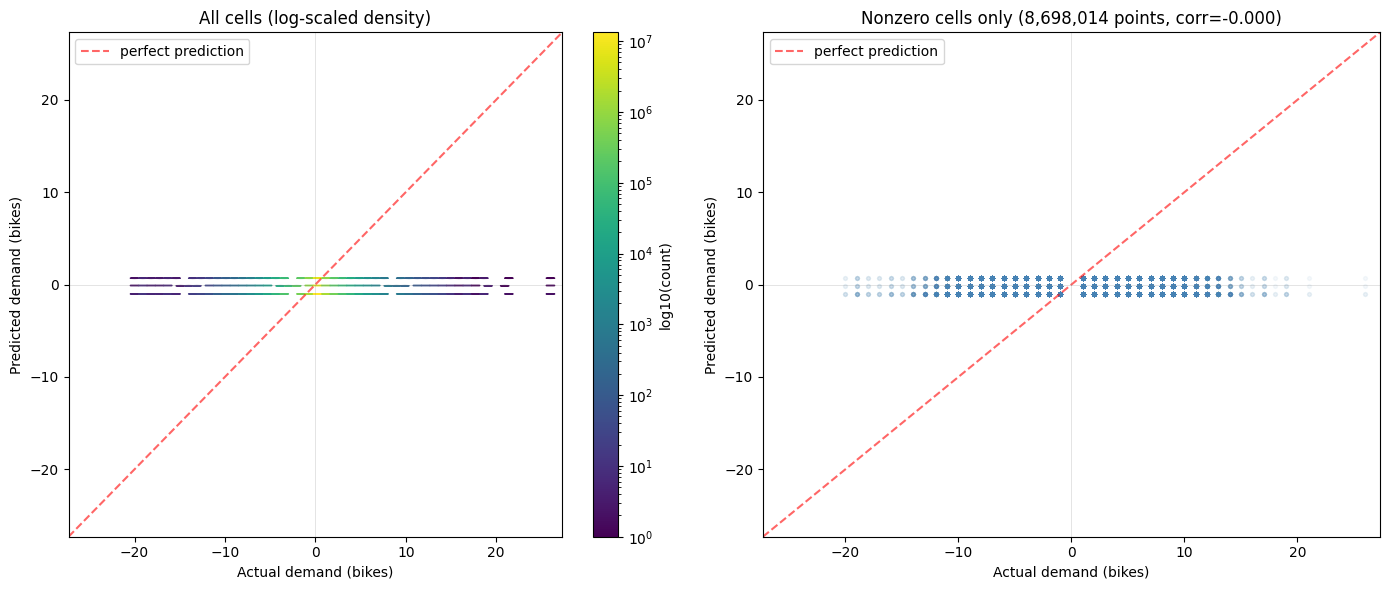

In [33]:
model.load_state_dict(torch.load("best_model_flow.pt", map_location=device))

edge_data = edge_data.squeeze(1) if edge_data.dim() == 2 else edge_data
print(f"edge_data shape: {edge_data.shape}")
edge_index = edge_index.to(device)
edge_data = edge_data.to(device)
import matplotlib.pyplot as plt
import numpy as np

# 1. Run predictions on the full test set
model.eval()
all_preds = []
all_targets = []
all_masks = []

with torch.no_grad():
    for x_b, y_b, m_b in test_loader:
        x_b = x_b.to(device)
        pred = model(x_b, edge_index, edge_data).cpu()
        all_preds.append(pred)
        all_targets.append(y_b)
        all_masks.append(m_b)

preds = torch.cat(all_preds, dim=0)
targets = torch.cat(all_targets, dim=0)
masks = torch.cat(all_masks, dim=0)

# 2. Flatten and apply mask
preds_flat = preds[masks].numpy()
targets_flat = targets[masks].numpy()
print(f"Plotting {len(preds_flat):,} (station, timestep) pairs")

# 3. Two-panel plot
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: full distribution
ax = axes[0]
hb = ax.hexbin(targets_flat, preds_flat, gridsize=50, bins='log', cmap='viridis', mincnt=1)
lim = max(abs(targets_flat).max(), abs(preds_flat).max()) * 1.05
ax.plot([-lim, lim], [-lim, lim], 'r--', alpha=0.6, label='perfect prediction')
ax.set_xlim(-lim, lim)
ax.set_ylim(-lim, lim)
ax.set_xlabel('Actual demand (bikes)')
ax.set_ylabel('Predicted demand (bikes)')
ax.set_title('All cells (log-scaled density)')
ax.legend(loc='upper left')
ax.axhline(0, color='gray', alpha=0.3, linewidth=0.5)
ax.axvline(0, color='gray', alpha=0.3, linewidth=0.5)
plt.colorbar(hb, ax=ax, label='log10(count)')

# Right: nonzero cells only
nz_mask = targets_flat != 0
ax = axes[1]
ax.scatter(targets_flat[nz_mask], preds_flat[nz_mask], alpha=0.05, s=8, color='steelblue')
nz_lim = max(abs(targets_flat[nz_mask]).max(), abs(preds_flat[nz_mask]).max()) * 1.05
ax.plot([-nz_lim, nz_lim], [-nz_lim, nz_lim], 'r--', alpha=0.6, label='perfect prediction')
ax.set_xlim(-nz_lim, nz_lim)
ax.set_ylim(-nz_lim, nz_lim)
ax.set_xlabel('Actual demand (bikes)')
ax.set_ylabel('Predicted demand (bikes)')
ax.set_title(f'Nonzero cells only ({nz_mask.sum():,} points)')
ax.legend(loc='upper left')
ax.axhline(0, color='gray', alpha=0.3, linewidth=0.5)
ax.axvline(0, color='gray', alpha=0.3, linewidth=0.5)

# add corr to title
from scipy.stats import pearsonr
corr, _ = pearsonr(targets_flat[nz_mask], preds_flat[nz_mask])
ax.set_title(f'Nonzero cells only ({nz_mask.sum():,} points, corr={corr:.3f})')

plt.tight_layout()
plt.savefig('pred_vs_actual.png', dpi=120, bbox_inches='tight')
plt.show()

In [55]:
dumy_iter = iter(test_loader)
x_a, y_a, m_a = next(dumy_iter)
y_a

tensor([[[ 0.,  0.,  1.,  1.],
         [ 0.,  1., -1.,  0.],
         [ 0.,  0.,  0.,  0.],
         ...,
         [ 0.,  0.,  0.,  0.],
         [ 0.,  0.,  0.,  0.],
         [ 0.,  0.,  0.,  0.]],

        [[ 0.,  1.,  1., -1.],
         [ 1., -1.,  0.,  0.],
         [ 0.,  0.,  0.,  0.],
         ...,
         [ 0.,  0.,  0.,  0.],
         [ 0.,  0.,  0.,  0.],
         [ 0.,  0.,  0.,  0.]],

        [[ 1.,  1., -1.,  0.],
         [-1.,  0.,  0.,  0.],
         [ 0.,  0.,  0.,  0.],
         ...,
         [ 0.,  0.,  0.,  0.],
         [ 0.,  0.,  0.,  0.],
         [ 0.,  0.,  0.,  0.]],

        ...,

        [[-3.,  0.,  0.,  0.],
         [-1., -1.,  0.,  0.],
         [ 0.,  0.,  0.,  0.],
         ...,
         [ 0.,  0.,  0.,  0.],
         [ 0.,  0.,  0.,  0.],
         [ 0.,  0.,  0.,  0.]],

        [[ 0.,  0.,  0.,  0.],
         [-1.,  0.,  0., -1.],
         [ 0.,  0.,  0.,  0.],
         ...,
         [ 0.,  0.,  0.,  0.],
         [ 0.,  0.,  0.,  0.],
         

In [68]:
with torch.no_grad():
      x_a = x_a.to(device)
      y_hat_a = model(x_a, edge_index, edge_data).cpu()

masked_weighted_l1(y_hat_a, y_a, m_a, 50)

tensor(1.5089)

In [63]:
y_a - y_hat_a

tensor([[[-0.0893, -0.0037,  0.8928,  1.1517],
         [-0.0062,  1.0435, -1.0854,  0.1360],
         [-0.0062,  0.0435, -0.0854,  0.1360],
         ...,
         [-0.0210,  0.0353, -0.0893,  0.1271],
         [-0.0227,  0.0346, -0.0897,  0.1261],
         [-0.0119,  0.0391, -0.0875,  0.1319]],

        [[-0.0702,  1.0121,  0.9049, -0.8573],
         [ 0.9938, -0.9565, -0.0854,  0.1360],
         [-0.0062,  0.0435, -0.0854,  0.1360],
         ...,
         [-0.0210,  0.0353, -0.0893,  0.1271],
         [-0.0227,  0.0346, -0.0897,  0.1261],
         [-0.0119,  0.0391, -0.0875,  0.1319]],

        [[ 0.9466,  1.0231, -1.0882,  0.1384],
         [-1.0439, -0.0178, -0.1424,  0.1913],
         [-0.0062,  0.0435, -0.0854,  0.1360],
         ...,
         [-0.0210,  0.0353, -0.0893,  0.1271],
         [-0.0227,  0.0346, -0.0897,  0.1261],
         [-0.0119,  0.0391, -0.0875,  0.1319]],

        ...,

        [[-3.2013, -0.0384, -0.1548,  0.1561],
         [-1.1832, -1.0816, -0.2020,  0.1898]

In [40]:
type(preds)

torch.Tensor

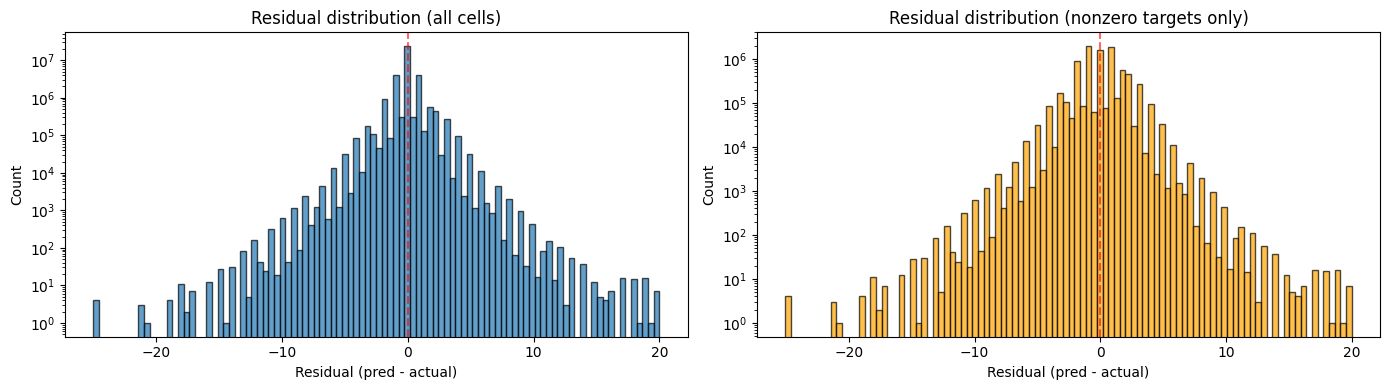

In [ ]:
residuals = preds_flat - targets_flat
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(residuals, bins=100, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Residual (pred - actual)')
axes[0].set_ylabel('Count')
axes[0].set_title('Residual distribution (all cells)')
axes[0].axvline(0, color='red', linestyle='--', alpha=0.6)
axes[0].set_yscale('log')

axes[1].hist(residuals[targets_flat != 0], bins=100, edgecolor='black', alpha=0.7, color='orange')
axes[1].set_xlabel('Residual (pred - actual)')
axes[1].set_ylabel('Count')
axes[1].set_title('Residual distribution (nonzero targets only)')
axes[1].axvline(0, color='red', linestyle='--', alpha=0.6)
axes[1].set_yscale('log')

plt.tight_layout()
plt.savefig('residuals.png', dpi=120, bbox_inches='tight')
plt.show()